In [181]:
import requests
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

In [98]:
# Sierra at Tahoe resort API call

url = "https://archive-api.open-meteo.com/v1/archive"

sierra_params = {
    "latitude": 38.8002,
	"longitude": -120.0806,
	"start_date": "1940-01-19",
	"end_date": "2025-01-19",
	"daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "wind_speed_10m_max", "snowfall_sum", "rain_sum", "shortwave_radiation_sum"],
	"timezone": "America/Los_Angeles",
    "temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
}

sierra_response = requests.get(url, params = sierra_params)
response.raise_for_status()

In [99]:
sierra_result = sierra_response.json()
sierra_daily = sierra_result["daily"]

sierra_df = pd.DataFrame(sierra_daily)
sierra_df["time"] = pd.to_datetime(sierra_df["time"])
sierra_df = sierra_df.rename(columns={"time": "date"})
sierra_df = sierra_df[sierra_df['date'].dt.year != 2025]
sierra_df.insert(3, 'temp_mean', (sierra_df['temperature_2m_max'] + sierra_df['temperature_2m_min']) / 2)

sierra_df

,date,temperature_2m_max,temperature_2m_min,temp_mean,precipitation_sum,wind_speed_10m_max,snowfall_sum,rain_sum,shortwave_radiation_sum
0,1940-01-19,29.2,16.6,22.90,0.016,6.0,0.110,0.000,5.58
1,1940-01-20,31.8,12.8,22.30,0.000,5.0,0.000,0.000,11.84
2,1940-01-21,30.6,14.1,22.35,0.000,3.9,0.000,0.000,8.24
3,1940-01-22,35.2,13.9,24.55,0.000,4.6,0.000,0.000,10.78
4,1940-01-23,32.9,20.6,26.75,0.213,4.3,1.488,0.000,5.13
...,...,...,...,...,...,...,...,...,...
31024,2024-12-27,38.2,28.3,33.25,0.504,13.6,2.315,0.173,6.03
31025,2024-12-28,37.4,29.2,33.30,0.260,6.6,0.000,0.260,1.93
31026,2024-12-29,34.5,27.7,31.10,1.091,20.2,4.602,0.433,1.40
31027,2024-12-30,39.8,12.3,26.05,0.004,7.1,0.000,0.004,10.89


In [100]:
sierra_df['year'] = sierra_df['date'].dt.year
sierra_annual_totals = sierra_df.groupby('year')[['precipitation_sum','snowfall_sum','rain_sum']].sum().reset_index()
sierra_annual_totals.columns = ['year','precipitation_inches','snowfall_inches','rain_inches']
sierra_annual_totals

,year,precipitation_inches,snowfall_inches,rain_inches
0,1940,38.534,231.769,5.428
1,1941,41.309,221.361,9.693
2,1942,38.379,239.493,4.177
3,1943,29.816,171.199,5.360
4,1944,29.213,179.749,3.532
...,...,...,...,...
80,2020,34.195,208.789,4.393
81,2021,50.507,291.272,8.926
82,2022,43.406,236.900,9.577
83,2023,61.021,331.758,13.661


In [101]:
sierra_df['snow_days'] = sierra_df['snowfall_sum'] > 0

sierra_snow_day_counts = sierra_df.groupby('year')['snow_days'].sum().reset_index()
sierra_snow_day_counts.columns = ['year', 'snow_days']
sierra_snow_day_counts

,year,snow_days
0,1940,90
1,1941,118
2,1942,104
3,1943,77
4,1944,101
...,...,...
80,2020,75
81,2021,81
82,2022,65
83,2023,96


In [102]:
sierra_df['month'] = sierra_df['date'].dt.month
sierra_winter_df = sierra_df[sierra_df['month'].isin([12, 1, 2])] # I used AI to help with this line of code
sierra_winter_averages = sierra_winter_df.groupby('year')[['snowfall_sum','precipitation_sum','rain_sum','temp_mean']].mean().reset_index()
sierra_winter_averages = sierra_winter_averages.rename(columns={
    'snowfall_sum':'avg_winter_snow',
    'precipitation_sum':'avg_winter_precip',
    'rain_sum':'avg_winter_rain',
    'temp_mean':'avg_winter_temp'
})
sierra_winter_averages

,year,avg_winter_snow,avg_winter_precip,avg_winter_rain,avg_winter_temp
0,1940,2.091082,0.306384,0.007685,26.715068
1,1941,1.688800,0.258311,0.017078,24.798333
2,1942,1.145889,0.167656,0.003989,24.843333
3,1943,1.140656,0.170222,0.007278,26.525556
4,1944,1.063967,0.155165,0.003176,23.299451
...,...,...,...,...,...
80,2020,0.698385,0.104011,0.004374,30.456593
81,2021,2.399767,0.352022,0.009511,28.837778
82,2022,1.444711,0.254311,0.047989,29.566111
83,2023,2.223100,0.330011,0.012656,27.641667


In [103]:
sierra_df['extreme_snow'] = sierra_df['snowfall_sum'] >= 10
sierra_extreme_snow_days = sierra_df.groupby('year')['extreme_snow'].sum().reset_index()
sierra_extreme_snow_days = sierra_extreme_snow_days.rename(columns={'extreme_snow':'extreme_snow_days'})
sierra_extreme_snow_days

,year,extreme_snow_days
0,1940,4
1,1941,2
2,1942,3
3,1943,4
4,1944,3
...,...,...
80,2020,6
81,2021,9
82,2022,7
83,2023,9


In [104]:
sierra_annual_mean_temps = sierra_df.groupby('year')[['temp_mean']].mean().reset_index()
sierra_annual_mean_temps

,year,temp_mean
0,1940,40.016954
1,1941,37.190274
2,1942,38.264247
3,1943,39.645479
4,1944,38.005738
...,...,...
80,2020,43.837568
81,2021,43.739589
82,2022,42.661918
83,2023,40.934658


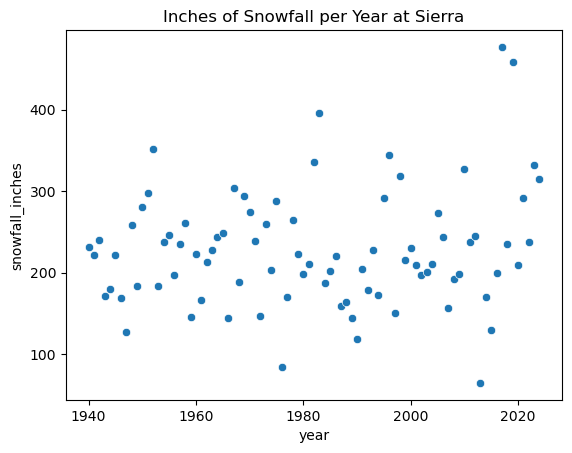

In [115]:
sb.scatterplot(data = sierra_annual_totals, x='year', y='snowfall_inches')
plt.title('Inches of Snowfall per Year at Sierra')
plt.show()

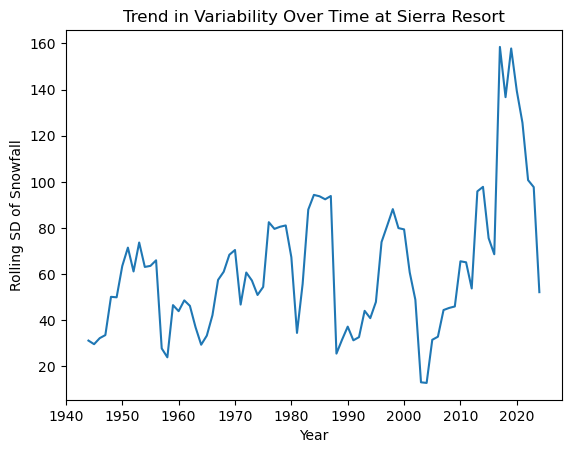

In [225]:
sierra_sd = sierra_annual_totals.sort_values('year')
sierra_sd['sierr_rolling_sd'] = sierra_sd['snowfall_inches'].rolling(window=5).std()

plt.plot(sierra_sd['year'], sierra_sd['sierr_rolling_sd'])
plt.xlabel('Year')
plt.ylabel('Rolling SD of Snowfall')
plt.title('Trend in Variability Over Time at Sierra Resort')
plt.show()

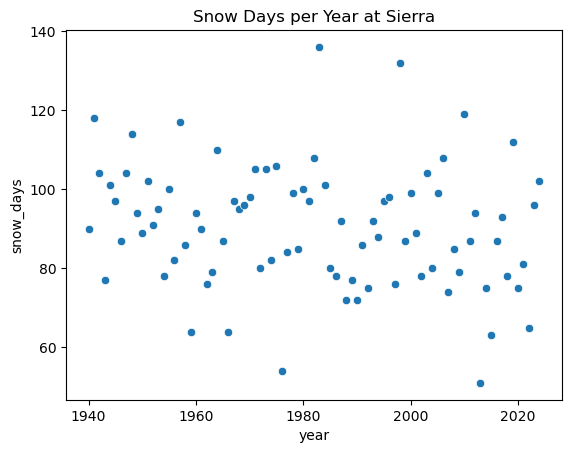

In [116]:
sb.scatterplot(data = sierra_snow_day_counts, x='year', y='snow_days')
plt.title('Snow Days per Year at Sierra')
plt.show()

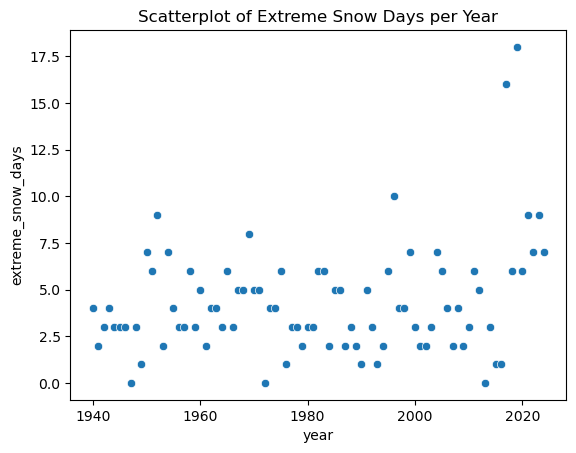

In [179]:
sb.scatterplot(data = sierra_extreme_snow_days, x='year', y='extreme_snow_days')
plt.title('Scatterplot of Extreme Snow Days per Year')
plt.show()

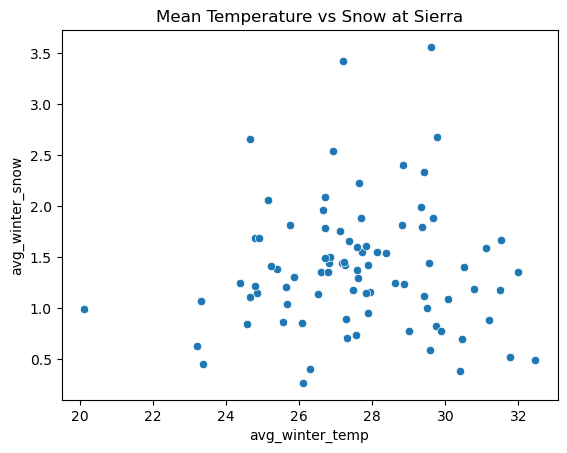

In [118]:
sb.scatterplot(data = sierra_winter_averages, x='avg_winter_temp', y='avg_winter_snow')
plt.title('Mean Temperature vs Snow at Sierra')
plt.show()

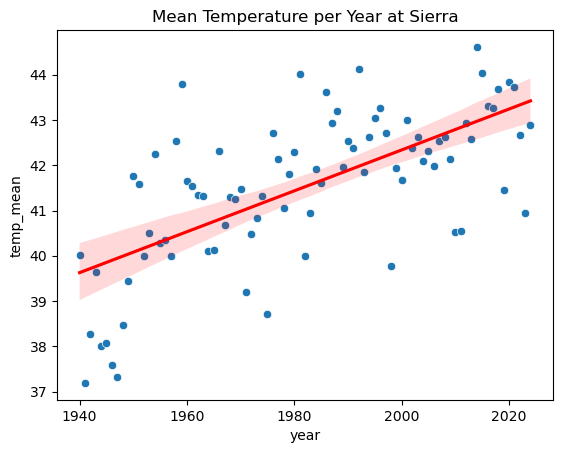

In [200]:
sb.scatterplot(data = sierra_annual_mean_temps, x='year', y='temp_mean')
plt.title('Mean Temperature per Year at Sierra')
sb.regplot(data=sierra_annual_mean_temps, x='year', y='temp_mean',
            scatter=False, color='red')
plt.show()

In [168]:
x = sierra_annual_mean_temps[['year']]
y = sierra_annual_mean_temps['temp_mean']

x = sm.add_constant(x) # I used AI to help with this line
model = sm.OLS(y, x).fit()

print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)

R-squared: 0.44194092762777937
Adjusted R-squared: 0.43521732434618643


In [235]:
sierra_residuals = model.resid
fitted = model.fittedvalues
bp_test = het_breuschpagan(sierra_residuals, x)
labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test))) # I used AI to help with this line

{'LM Statistic': np.float64(3.0865819636471303), 'LM Test p-value': np.float64(0.0789404666990998), 'F-Statistic': np.float64(3.127525491232915), 'F-Test p-value': np.float64(0.08065468020899508)}


In [236]:
shapiro_test = stats.shapiro(sierra_residuals)
print("Shapiro-Wilk Test:", shapiro_test)

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9708378762252545), pvalue=np.float64(0.05098225018091536))


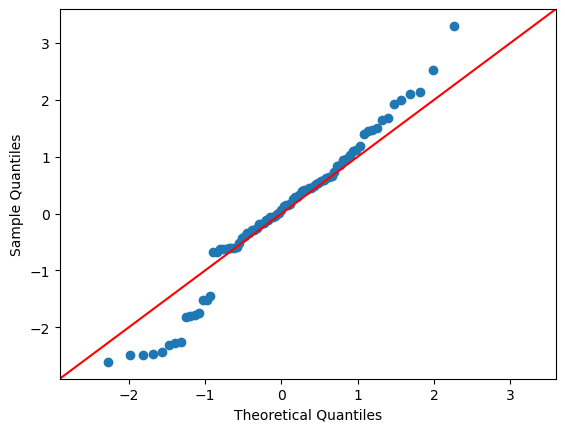

In [237]:
sm.qqplot(sierra_residuals, line='45')
plt.show()

In [112]:
# Heavanly Mountain resort API call

heavanly_params = {
    "latitude": 38.9287,
	"longitude": -119.9051,
	"start_date": "1940-01-19",
	"end_date": "2025-01-19",
	"daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "wind_speed_10m_max", "snowfall_sum", "rain_sum", "shortwave_radiation_sum"],
	"timezone": "America/Los_Angeles",
    "temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
}

heavenly_response = requests.get(url, params = heavanly_params)
response.raise_for_status()

In [125]:
heavenly_result = heavenly_response.json()
heavenly_daily = heavenly_result["daily"]

heavenly_df = pd.DataFrame(heavenly_daily)
heavenly_df["time"] = pd.to_datetime(heavenly_df["time"])
heavenly_df = heavenly_df.rename(columns={"time": "date"})
heavenly_df = heavenly_df[heavenly_df['date'].dt.year != 2025]
heavenly_df.insert(3, 'temp_mean', (heavenly_df['temperature_2m_max'] + heavenly_df['temperature_2m_min']) / 2)

heavenly_df

,date,temperature_2m_max,temperature_2m_min,temp_mean,precipitation_sum,wind_speed_10m_max,snowfall_sum,rain_sum,shortwave_radiation_sum
0,1940-01-19,21.0,8.4,14.70,0.016,6.0,0.110,0.000,5.58
1,1940-01-20,23.5,4.5,14.00,0.000,5.0,0.000,0.000,11.84
2,1940-01-21,22.3,5.8,14.05,0.000,3.9,0.000,0.000,8.24
3,1940-01-22,26.9,5.7,16.30,0.000,4.6,0.000,0.000,10.78
4,1940-01-23,24.6,12.3,18.45,0.213,4.3,1.488,0.000,5.13
...,...,...,...,...,...,...,...,...,...
31024,2024-12-27,30.4,21.7,26.05,0.409,28.9,2.453,0.059,6.90
31025,2024-12-28,30.9,23.5,27.20,0.169,16.6,0.055,0.161,2.35
31026,2024-12-29,26.9,19.9,23.40,0.929,24.9,6.118,0.055,1.49
31027,2024-12-30,28.7,10.5,19.60,0.000,7.7,0.000,0.000,10.85


In [126]:
heavenly_df['year'] = heavenly_df['date'].dt.year
heavenly_annual_totals = heavenly_df.groupby('year')[['precipitation_sum','snowfall_sum','rain_sum']].sum().reset_index()
heavenly_annual_totals.columns = ['year','precipitation_inches','snowfall_inches','rain_inches']
heavenly_annual_totals

,year,precipitation_inches,snowfall_inches,rain_inches
0,1940,38.534,231.769,5.428
1,1941,41.309,221.361,9.693
2,1942,38.379,239.493,4.177
3,1943,29.816,171.199,5.360
4,1944,29.213,179.749,3.532
...,...,...,...,...
80,2020,23.932,151.026,2.392
81,2021,42.394,259.135,5.423
82,2022,38.361,221.770,6.707
83,2023,48.147,281.932,7.898


In [127]:
heavenly_df['snow_days'] = heavenly_df['snowfall_sum'] > 0

heavenly_snow_day_counts = heavenly_df.groupby('year')['snow_days'].sum().reset_index()
heavenly_snow_day_counts.columns = ['year', 'snow_days']
heavenly_snow_day_counts

,year,snow_days
0,1940,90
1,1941,118
2,1942,104
3,1943,77
4,1944,101
...,...,...
80,2020,78
81,2021,86
82,2022,69
83,2023,103


In [128]:
heavenly_df['month'] = heavenly_df['date'].dt.month
heavenly_winter_df = heavenly_df[heavenly_df['month'].isin([12, 1, 2])]
heavenly_winter_averages = heavenly_winter_df.groupby('year')[['snowfall_sum','precipitation_sum','rain_sum','temp_mean']].mean().reset_index()
heavenly_winter_averages = heavenly_winter_averages.rename(columns={
    'snowfall_sum':'avg_winter_snow',
    'precipitation_sum':'avg_winter_precip',
    'rain_sum':'avg_winter_rain',
    'temp_mean':'avg_winter_temp'
})
heavenly_winter_averages

,year,avg_winter_snow,avg_winter_precip,avg_winter_rain,avg_winter_temp
0,1940,2.091082,0.306384,0.007685,18.436986
1,1941,1.688800,0.258311,0.017078,16.517778
2,1942,1.145889,0.167656,0.003989,16.561111
3,1943,1.140656,0.170222,0.007278,18.244444
4,1944,1.063967,0.155165,0.003176,15.019231
...,...,...,...,...,...
80,2020,0.524253,0.075978,0.001165,22.583516
81,2021,2.062311,0.295411,0.001244,21.315556
82,2022,1.513000,0.231767,0.015833,21.600000
83,2023,1.867011,0.270844,0.004211,19.248333


In [129]:
heavenly_df['extreme_snow'] = heavenly_df['snowfall_sum'] >= 10
heavenly_extreme_snow_days = heavenly_df.groupby('year')['extreme_snow'].sum().reset_index()
heavenly_extreme_snow_days = heavenly_extreme_snow_days.rename(columns={'extreme_snow':'extreme_snow_days'})
heavenly_extreme_snow_days

,year,extreme_snow_days
0,1940,4
1,1941,2
2,1942,3
3,1943,4
4,1944,3
...,...,...
80,2020,4
81,2021,8
82,2022,8
83,2023,8


In [130]:
heavenly_annual_mean_temps = heavenly_df.groupby('year')[['temp_mean']].mean().reset_index()
heavenly_annual_mean_temps

,year,temp_mean
0,1940,31.736782
1,1941,28.909726
2,1942,29.984658
3,1943,31.365890
4,1944,29.725820
...,...,...
80,2020,36.384426
81,2021,36.319452
82,2022,35.279726
83,2023,33.438493


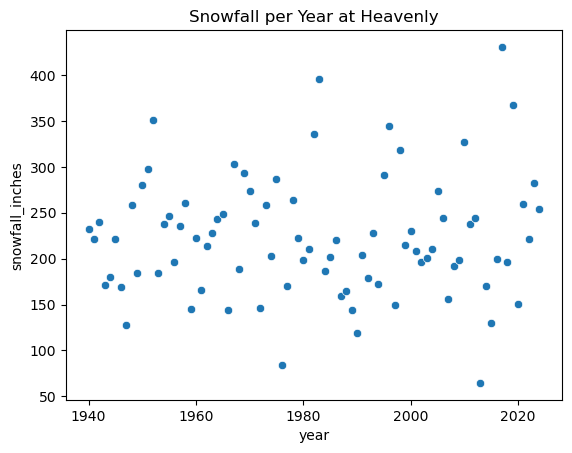

In [131]:
sb.scatterplot(data = heavenly_annual_totals, x='year', y='snowfall_inches')
plt.title('Snowfall per Year at Heavenly')
plt.show()

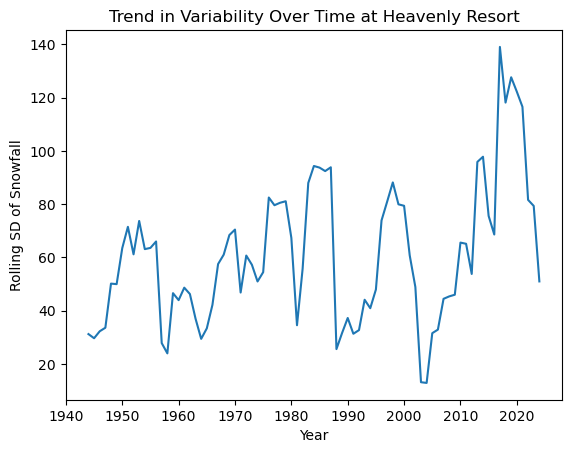

In [226]:
heavenly_sd = heavenly_annual_totals.sort_values('year')
heavenly_sd['heavenly_rolling_sd'] = heavenly_sd['snowfall_inches'].rolling(window=5).std()

plt.plot(heavenly_sd['year'], heavenly_sd['heavenly_rolling_sd'])
plt.xlabel('Year')
plt.ylabel('Rolling SD of Snowfall')
plt.title('Trend in Variability Over Time at Heavenly Resort')
plt.show()

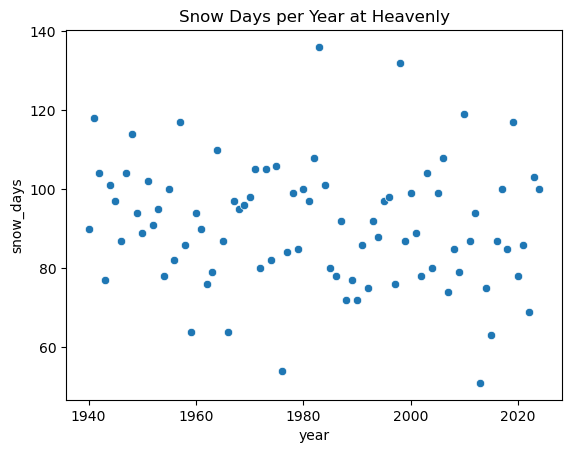

In [132]:
sb.scatterplot(data = heavenly_snow_day_counts, x='year', y='snow_days')
plt.title('Snow Days per Year at Heavenly')
plt.show()

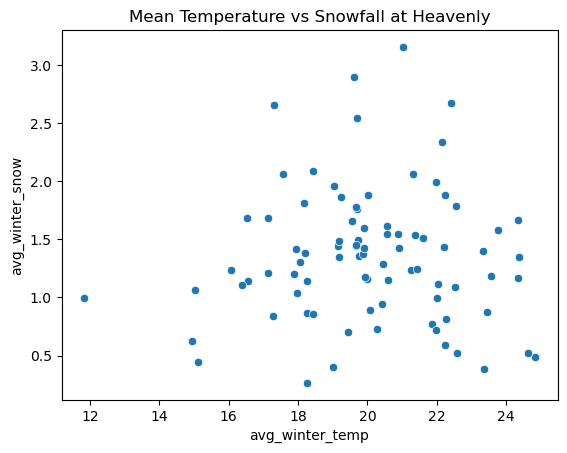

In [133]:
sb.scatterplot(data = heavenly_winter_averages, x='avg_winter_temp', y='avg_winter_snow')
plt.title('Mean Temperature vs Snowfall at Heavenly')
plt.show()

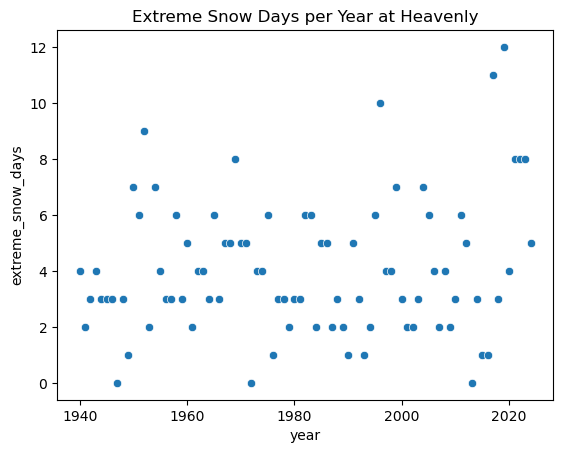

In [134]:
sb.scatterplot(data = heavenly_extreme_snow_days, x='year', y='extreme_snow_days')
plt.title('Extreme Snow Days per Year at Heavenly')
plt.show()

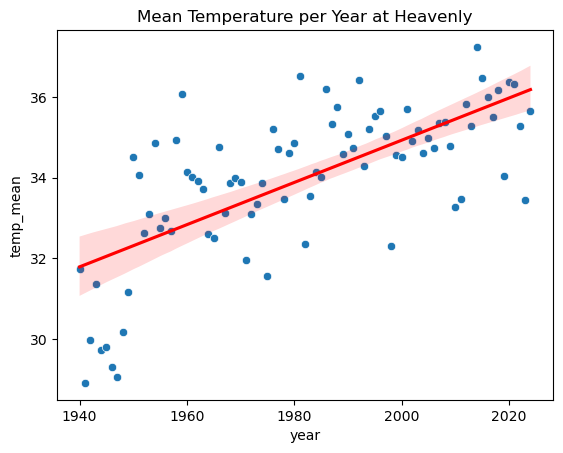

In [135]:
sb.scatterplot(data = heavenly_annual_mean_temps, x='year', y='temp_mean')
plt.title('Mean Temperature per Year at Heavenly')
sb.regplot(data=heavenly_annual_mean_temps, x='year', y='temp_mean',
            scatter=False, color='red')
plt.show()

In [136]:
# Kirkwood resort API call

kirkwood_params = {
    "latitude": 38.6830,
	"longitude": -120.0665,
	"start_date": "1940-01-19",
	"end_date": "2025-01-19",
	"daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "wind_speed_10m_max", "snowfall_sum", "rain_sum", "shortwave_radiation_sum"],
	"timezone": "America/Los_Angeles",
    "temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
}

kirkwood_response = requests.get(url, params = kirkwood_params)
response.raise_for_status()

In [137]:
kirkwood_result = kirkwood_response.json()
kirkwood_daily = kirkwood_result["daily"]

kirkwood_df = pd.DataFrame(kirkwood_daily)
kirkwood_df["time"] = pd.to_datetime(kirkwood_df["time"])
kirkwood_df = kirkwood_df.rename(columns={"time": "date"})
kirkwood_df = kirkwood_df[kirkwood_df['date'].dt.year != 2025]
kirkwood_df.insert(3, 'temp_mean', (kirkwood_df['temperature_2m_max'] + kirkwood_df['temperature_2m_min']) / 2)

kirkwood_df

,date,temperature_2m_max,temperature_2m_min,temp_mean,precipitation_sum,wind_speed_10m_max,snowfall_sum,rain_sum,shortwave_radiation_sum
0,1940-01-19,28.2,12.2,20.20,0.008,5.5,0.055,0.000,7.12
1,1940-01-20,30.6,9.3,19.95,0.000,4.5,0.000,0.000,12.30
2,1940-01-21,29.7,10.3,20.00,0.000,3.1,0.000,0.000,8.50
3,1940-01-22,33.8,9.7,21.75,0.000,4.5,0.000,0.000,11.96
4,1940-01-23,31.7,17.3,24.50,0.173,4.6,1.213,0.000,5.70
...,...,...,...,...,...,...,...,...,...
31024,2024-12-27,37.1,27.9,32.50,0.469,25.8,3.087,0.028,7.74
31025,2024-12-28,36.7,31.6,34.15,0.083,19.1,0.000,0.083,2.44
31026,2024-12-29,33.6,26.1,29.85,0.866,23.1,5.870,0.028,1.40
31027,2024-12-30,39.0,11.9,25.45,0.000,9.3,0.000,0.000,11.09


In [138]:
kirkwood_df['year'] = kirkwood_df['date'].dt.year
kirkwood_annual_totals = kirkwood_df.groupby('year')[['precipitation_sum','snowfall_sum','rain_sum']].sum().reset_index()
kirkwood_annual_totals.columns = ['year','precipitation_inches','snowfall_inches','rain_inches']
kirkwood_annual_totals

,year,precipitation_inches,snowfall_inches,rain_inches
0,1940,33.193,199.198,4.750
1,1941,37.033,203.357,7.986
2,1942,32.746,211.637,2.520
3,1943,26.198,156.040,3.907
4,1944,24.877,156.755,2.507
...,...,...,...,...
80,2020,24.002,154.802,1.924
81,2021,42.710,268.758,4.348
82,2022,38.465,228.822,5.793
83,2023,52.843,312.052,8.278


In [139]:
kirkwood_df['snow_days'] = kirkwood_df['snowfall_sum'] > 0

kirkwood_snow_day_counts = kirkwood_df.groupby('year')['snow_days'].sum().reset_index()
kirkwood_snow_day_counts.columns = ['year', 'snow_days']
kirkwood_snow_day_counts

,year,snow_days
0,1940,90
1,1941,120
2,1942,105
3,1943,82
4,1944,101
...,...,...
80,2020,77
81,2021,91
82,2022,67
83,2023,102


In [140]:
kirkwood_df['month'] = kirkwood_df['date'].dt.month
kirkwood_winter_df = kirkwood_df[kirkwood_df['month'].isin([12, 1, 2])]
kirkwood_winter_averages = kirkwood_winter_df.groupby('year')[['snowfall_sum','precipitation_sum','rain_sum','temp_mean']].mean().reset_index()
kirkwood_winter_averages = kirkwood_winter_averages.rename(columns={
    'snowfall_sum':'avg_winter_snow',
    'precipitation_sum':'avg_winter_precip',
    'rain_sum':'avg_winter_rain',
    'temp_mean':'avg_winter_temp'
})
kirkwood_winter_averages

,year,avg_winter_snow,avg_winter_precip,avg_winter_rain,avg_winter_temp
0,1940,1.821178,0.261822,0.001740,24.906164
1,1941,1.539922,0.225856,0.005878,22.393889
2,1942,0.932789,0.134156,0.000933,22.777222
3,1943,1.073889,0.156011,0.002578,24.153889
4,1944,0.913385,0.131198,0.000824,20.651099
...,...,...,...,...,...
80,2020,0.542099,0.078055,0.000747,27.862637
81,2021,2.146556,0.306822,0.000444,26.581111
82,2022,1.674689,0.242300,0.003022,26.636111
83,2023,2.063856,0.296900,0.002189,24.663333


In [141]:
kirkwood_df['extreme_snow'] = kirkwood_df['snowfall_sum'] >= 10
kirkwood_extreme_snow_days = kirkwood_df.groupby('year')['extreme_snow'].sum().reset_index()
kirkwood_extreme_snow_days = kirkwood_extreme_snow_days.rename(columns={'extreme_snow':'extreme_snow_days'})
kirkwood_extreme_snow_days

,year,extreme_snow_days
0,1940,3
1,1941,2
2,1942,2
3,1943,3
4,1944,2
...,...,...
80,2020,5
81,2021,7
82,2022,7
83,2023,10


In [142]:
kirkwood_annual_mean_temps = kirkwood_df.groupby('year')[['temp_mean']].mean().reset_index()
kirkwood_annual_mean_temps

,year,temp_mean
0,1940,38.332328
1,1941,35.121644
2,1942,36.507945
3,1943,37.698904
4,1944,36.065710
...,...,...
80,2020,42.199863
81,2021,41.949041
82,2022,40.930959
83,2023,39.176986


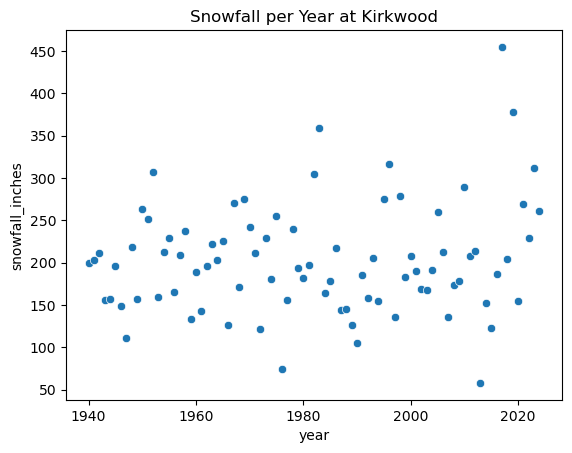

In [167]:
sb.scatterplot(data = kirkwood_annual_totals, x='year', y='snowfall_inches')
plt.title('Snowfall per Year at Kirkwood')
plt.show()

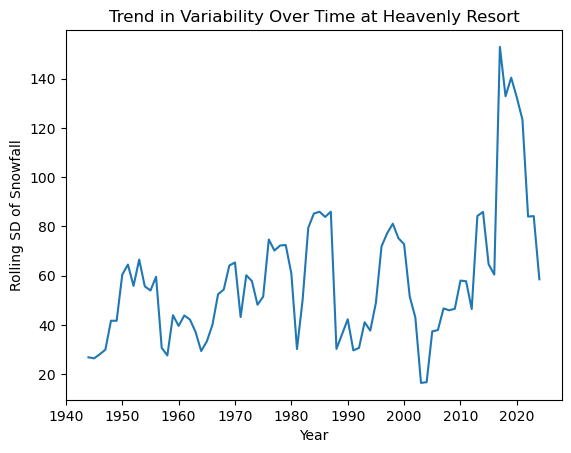

In [228]:
kirkwood_sd = kirkwood_annual_totals.sort_values('year')
kirkwood_sd['kirkwood_rolling_sd'] = kirkwood_sd['snowfall_inches'].rolling(window=5).std()

plt.plot(kirkwood_sd['year'], kirkwood_sd['kirkwood_rolling_sd'])
plt.xlabel('Year')
plt.ylabel('Rolling SD of Snowfall')
plt.title('Trend in Variability Over Time at Heavenly Resort')
plt.show()

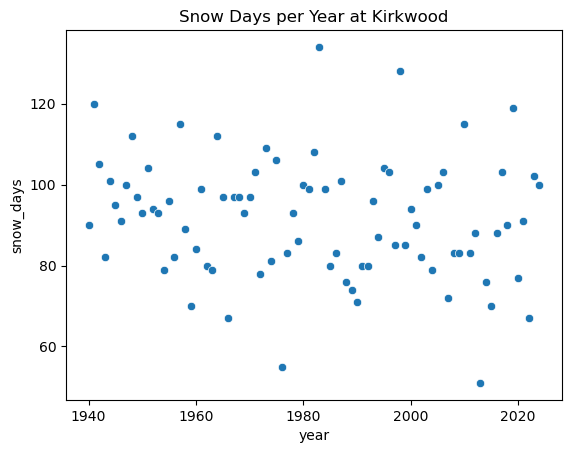

In [144]:
sb.scatterplot(data = kirkwood_snow_day_counts, x='year', y='snow_days')
plt.title('Snow Days per Year at Kirkwood')
plt.show()

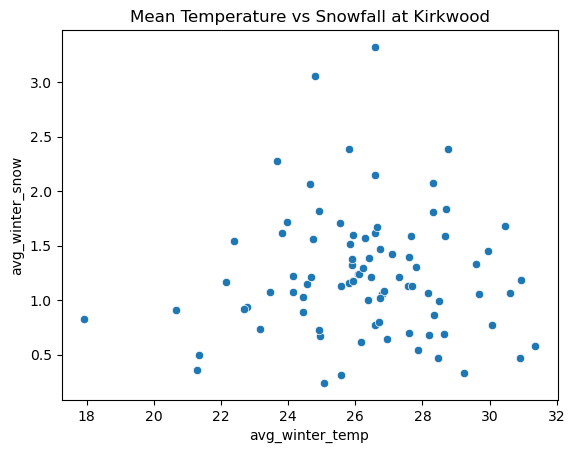

In [145]:
sb.scatterplot(data = kirkwood_winter_averages, x='avg_winter_temp', y='avg_winter_snow')
plt.title('Mean Temperature vs Snowfall at Kirkwood')
plt.show()

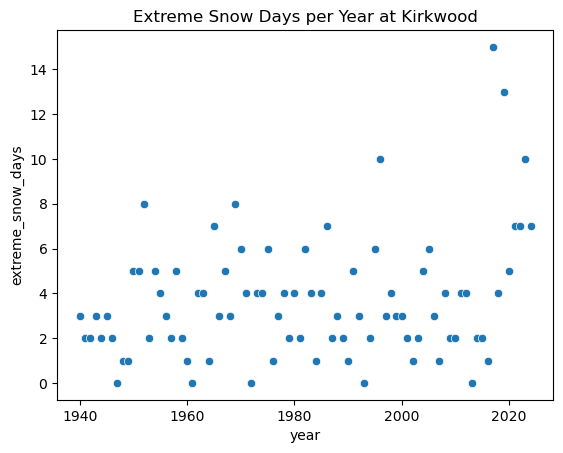

In [146]:
sb.scatterplot(data = kirkwood_extreme_snow_days, x='year', y='extreme_snow_days')
plt.title('Extreme Snow Days per Year at Kirkwood')
plt.show()

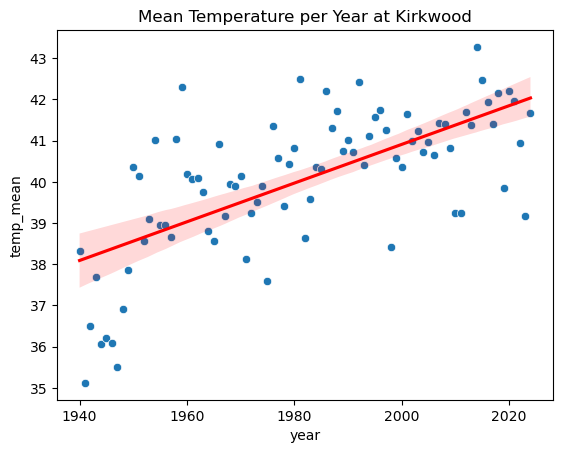

In [147]:
sb.scatterplot(data = kirkwood_annual_mean_temps, x='year', y='temp_mean')
plt.title('Mean Temperature per Year at Kirkwood')
sb.regplot(data=kirkwood_annual_mean_temps, x='year', y='temp_mean',
            scatter=False, color='red')
plt.show()

In [170]:
# Heavenly Linear Regression

heavenly_x = heavenly_annual_mean_temps[['year']]
heavenly_y = heavenly_annual_mean_temps['temp_mean']

heavenly_x = sm.add_constant(heavenly_x)
heavenly_model = sm.OLS(heavenly_y, heavenly_x).fit()

print("R-squared:", heavenly_model.rsquared)
print("Adjusted R-squared:", heavenly_model.rsquared_adj)

R-squared: 0.4814410247070454
Adjusted R-squared: 0.47519332620954


In [171]:
heavenly_residuals = heavenly_model.resid
heavenly_fitted = heavenly_model.fittedvalues
heavenly_bp_test = het_breuschpagan(heavenly_residuals, heavenly_x)
heavenly_labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(heavenly_labels, heavenly_bp_test))) # I used AI to help with this line

{'LM Statistic': np.float64(8.322396436215936), 'LM Test p-value': np.float64(0.003915922388716368), 'F-Statistic': np.float64(9.00861362511567), 'F-Test p-value': np.float64(0.003548480347587614)}


In [172]:
heavenly_shapiro_test = stats.shapiro(heavenly_residuals)
print("Shapiro-Wilk Test:", heavenly_shapiro_test)

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9699288204245269), pvalue=np.float64(0.04429424582884341))


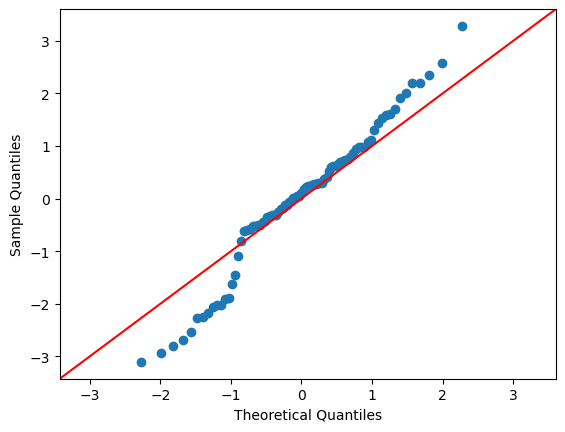

In [238]:
sm.qqplot(heavenly_residuals, line='45')
plt.show()

In [174]:
# Kirkwood Linear Regression

kirkwood_x = kirkwood_annual_mean_temps[['year']]
kirkwood_y = kirkwood_annual_mean_temps['temp_mean']

kirkwood_x = sm.add_constant(kirkwood_x)
kirkwood_model = sm.OLS(kirkwood_y, kirkwood_x).fit()

print("R-squared:", kirkwood_model.rsquared)
print("Adjusted R-squared:", kirkwood_model.rsquared_adj)

R-squared: 0.44806645784063126
Adjusted R-squared: 0.44141665612786785


In [175]:
kirkwood_residuals = kirkwood_model.resid
kirkwood_fitted = kirkwood_model.fittedvalues
kirkwood_bp_test = het_breuschpagan(kirkwood_residuals, kirkwood_x)
kirkwood_labels = ['LM Statistic', 'LM Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(kirkwood_labels, kirkwood_bp_test)))

{'LM Statistic': np.float64(4.962114399128911), 'LM Test p-value': np.float64(0.02590850947211445), 'F-Statistic': np.float64(5.145756812986292), 'F-Test p-value': np.float64(0.025899544563878468)}


In [176]:
kirkwood_shapiro_test = stats.shapiro(kirkwood_residuals)
print("Shapiro-Wilk Test:", kirkwood_shapiro_test)

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9693937471325472), pvalue=np.float64(0.0407833873121523))


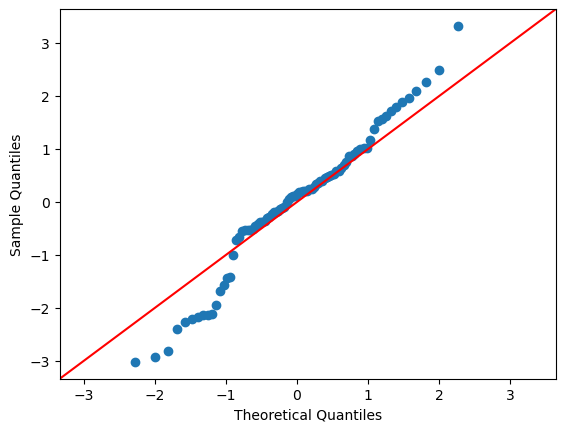

In [239]:
sm.qqplot(kirkwood_residuals, line='45')
plt.show()

In [156]:
sierra_df.to_csv('sierra_df.csv', index=False)

In [190]:
# Sierra Summary Statistics

sierra_annual_totals['snowfall_inches'].describe()

count     85.000000
mean     227.229812
std       71.372654
min       64.574000
25%      183.847000
50%      221.361000
75%      258.946000
max      476.806000
Name: snowfall_inches, dtype: float64

In [189]:
sierra_extreme_snow_days['extreme_snow_days'].describe()

count    85.000000
mean      4.305882
std       2.960146
min       0.000000
25%       3.000000
50%       4.000000
75%       6.000000
max      18.000000
Name: extreme_snow_days, dtype: float64

In [193]:
sierra_annual_mean_temps['temp_mean'].describe()

count    85.000000
mean     41.525192
std       1.677785
min      37.190274
25%      40.512055
50%      41.810000
75%      42.633562
max      44.615479
Name: temp_mean, dtype: float64

In [194]:
# Heavenly Summary Statistics

heavenly_annual_totals['snowfall_inches'].describe()

count     85.000000
mean     222.632706
std       65.454880
min       64.574000
25%      179.749000
50%      219.867000
75%      257.960000
max      430.668000
Name: snowfall_inches, dtype: float64

In [195]:
heavenly_extreme_snow_days['extreme_snow_days'].describe()

count    85.000000
mean      4.082353
std       2.416273
min       0.000000
25%       3.000000
50%       4.000000
75%       5.000000
max      12.000000
Name: extreme_snow_days, dtype: float64

In [196]:
heavenly_annual_mean_temps['temp_mean'].describe()

count    85.000000
mean     33.987398
std       1.862249
min      28.909726
25%      33.110383
50%      34.502186
75%      35.274110
max      37.244110
Name: temp_mean, dtype: float64

In [197]:
# Heavenly Summary Statistics

kirkwood_annual_totals['snowfall_inches'].describe()

count     85.000000
mean     202.836318
std       65.285271
min       57.847000
25%      157.448000
50%      196.137000
75%      229.046000
max      454.700000
Name: snowfall_inches, dtype: float64

In [198]:
kirkwood_extreme_snow_days['extreme_snow_days'].describe()

count    85.000000
mean      3.694118
std       2.730008
min       0.000000
25%       2.000000
50%       3.000000
75%       5.000000
max      15.000000
Name: extreme_snow_days, dtype: float64

In [199]:
kirkwood_annual_mean_temps['temp_mean'].describe()

count    85.000000
mean     40.062330
std       1.730219
min      35.121644
25%      39.164521
50%      40.368716
75%      41.308630
max      43.271918
Name: temp_mean, dtype: float64

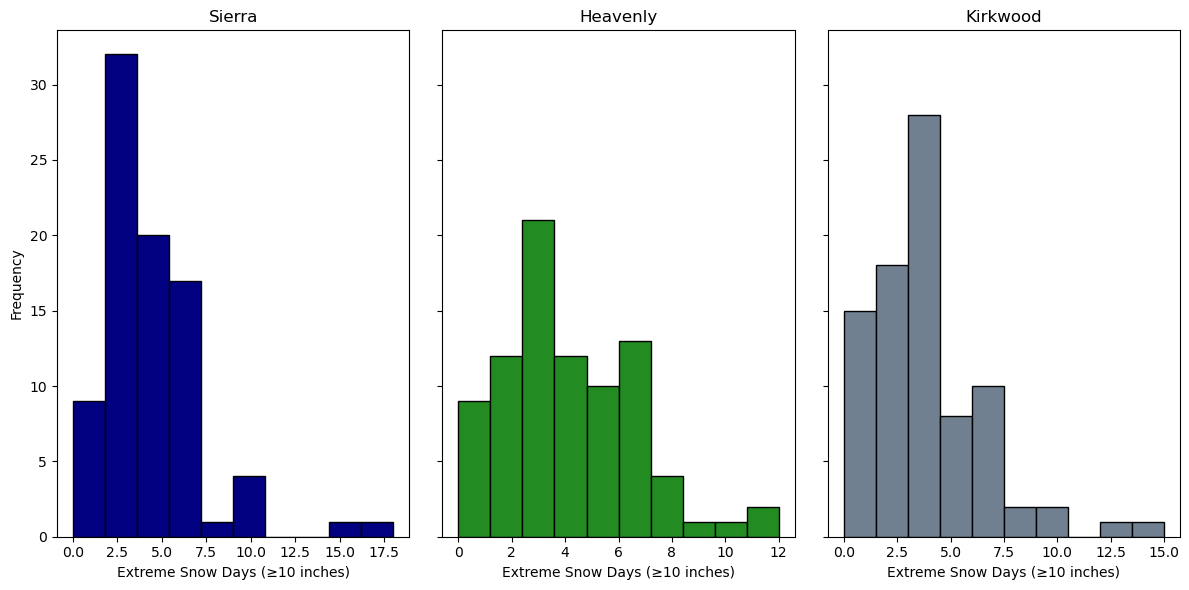

In [252]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

# Sierra
axes[0].hist(sierra_extreme_snow_days['extreme_snow_days'], bins=10, color='navy', edgecolor='black')
axes[0].set_title("Sierra")
axes[0].set_xlabel("Extreme Snow Days (≥10 inches)")
axes[0].set_ylabel("Frequency")

# Heavenly
axes[1].hist(heavenly_extreme_snow_days['extreme_snow_days'], bins=10, color='forestgreen', edgecolor='black')
axes[1].set_title("Heavenly")
axes[1].set_xlabel("Extreme Snow Days (≥10 inches)")

# Kirkwood
axes[2].hist(kirkwood_extreme_snow_days['extreme_snow_days'], bins=10, color='slategray', edgecolor='black')
axes[2].set_title("Kirkwood")
axes[2].set_xlabel("Extreme Snow Days (≥10 inches)")

plt.tight_layout()
plt.savefig("extreme_snow_day_counts.png", dpi=300, bbox_inches='tight') # I used AI for recommended settings
plt.show()

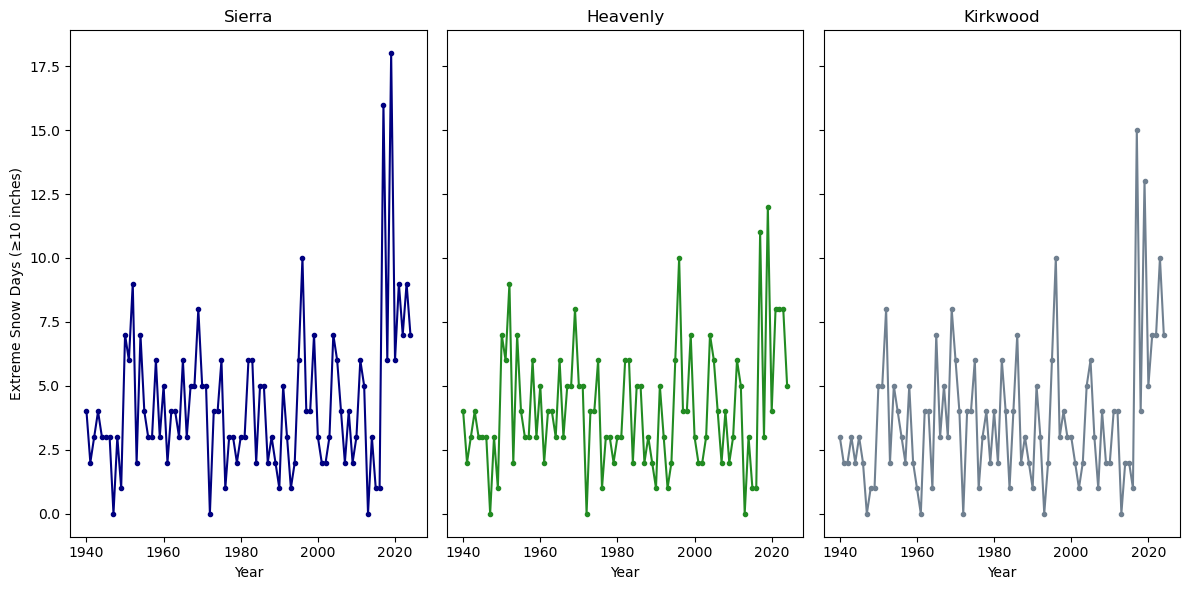

In [253]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

# Sierra
axes[0].plot(
    sierra_extreme_snow_days['year'],
    sierra_extreme_snow_days['extreme_snow_days'],
    color='navy',
    marker='.'
)
axes[0].set_title("Sierra")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Extreme Snow Days (≥10 inches)")


# Heavenly
axes[1].plot(
    heavenly_extreme_snow_days['year'],
    heavenly_extreme_snow_days['extreme_snow_days'],
    color='forestgreen',
    marker='.'
)
axes[1].set_title("Heavenly")
axes[1].set_xlabel("Year")

# Kirkwood
axes[2].plot(
    kirkwood_extreme_snow_days['year'],
    kirkwood_extreme_snow_days['extreme_snow_days'],
    color='slategray',
    marker='.'
)
axes[2].set_title("Kirkwood")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.savefig("extreme_snow_days_variation.png", dpi=300, bbox_inches='tight')
plt.show()

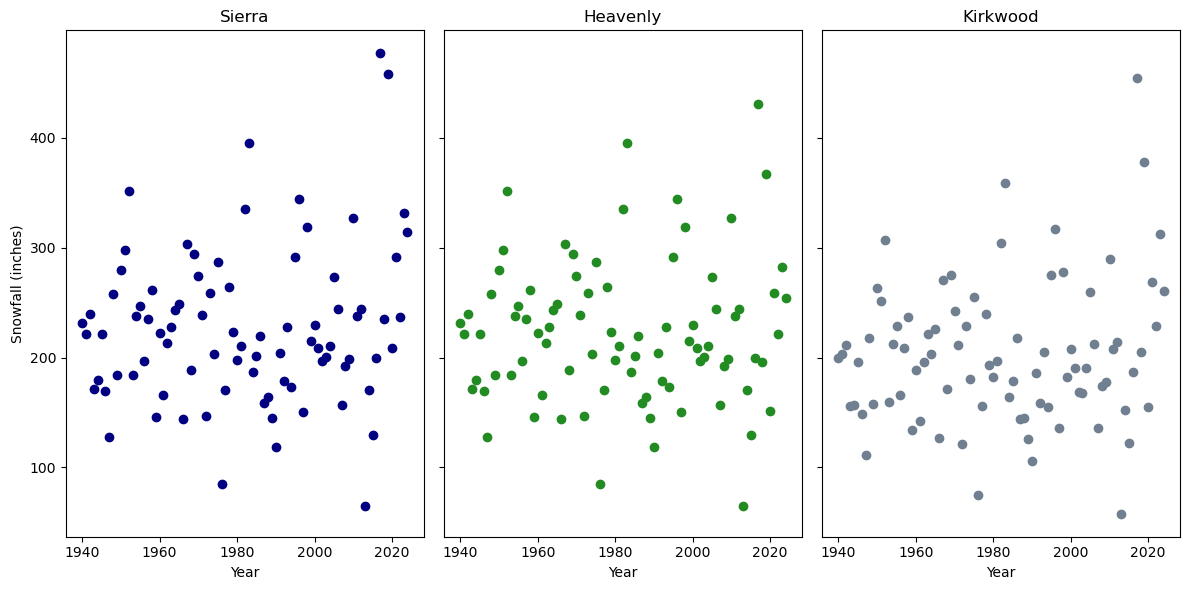

In [255]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

axes[0].scatter(sierra_annual_totals['year'], sierra_annual_totals['snowfall_inches'], color='navy')
axes[0].set_title("Sierra")

axes[1].scatter(heavenly_annual_totals['year'], heavenly_annual_totals['snowfall_inches'], color='forestgreen')
axes[1].set_title("Heavenly")

axes[2].scatter(kirkwood_annual_totals['year'], kirkwood_annual_totals['snowfall_inches'], color='slategray')
axes[2].set_title("Kirkwood")

axes[0].set_ylabel("Snowfall (inches)")
for ax in axes:
    ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig("total_snowfall.png", dpi=300, bbox_inches='tight')
plt.show()

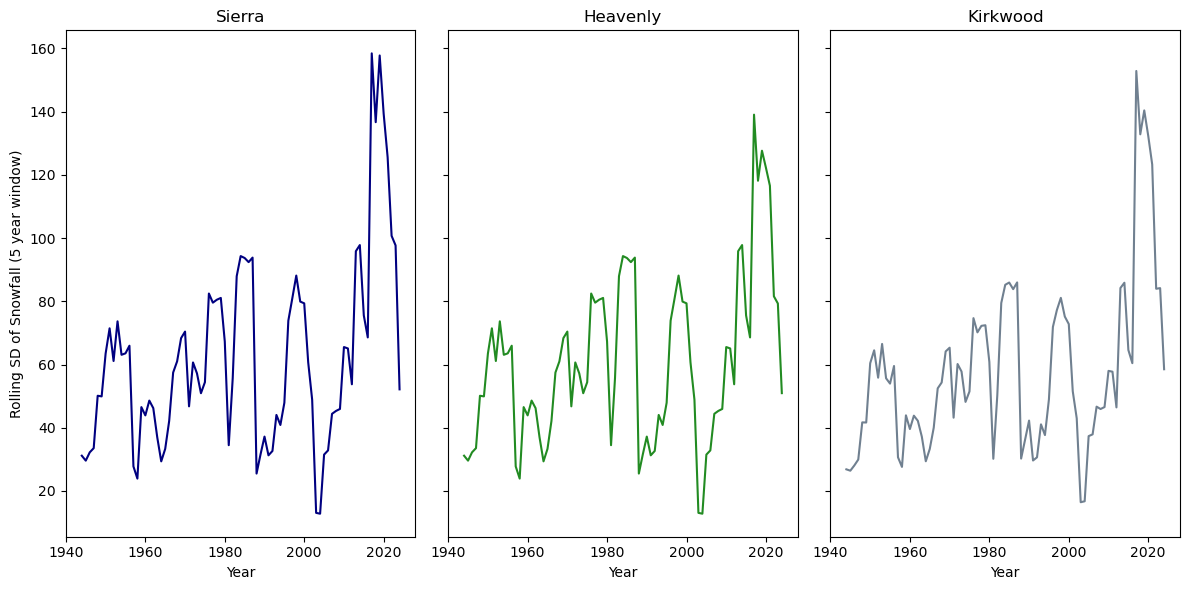

In [256]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

# Sierra
axes[0].plot(sierra_sd['year'], sierra_sd['sierr_rolling_sd'], color='navy')
axes[0].set_title("Sierra")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Rolling SD of Snowfall (5 year window)")

# Heavenly
axes[1].plot(heavenly_sd['year'], heavenly_sd['heavenly_rolling_sd'], color='forestgreen')
axes[1].set_title("Heavenly")
axes[1].set_xlabel("Year")

# Kirkwood
axes[2].plot(kirkwood_sd['year'], kirkwood_sd['kirkwood_rolling_sd'], color='slategray')
axes[2].set_title("Kirkwood")
axes[2].set_xlabel("Year")

plt.tight_layout()
plt.savefig("rolling_sd.png", dpi=300, bbox_inches='tight')
plt.show()

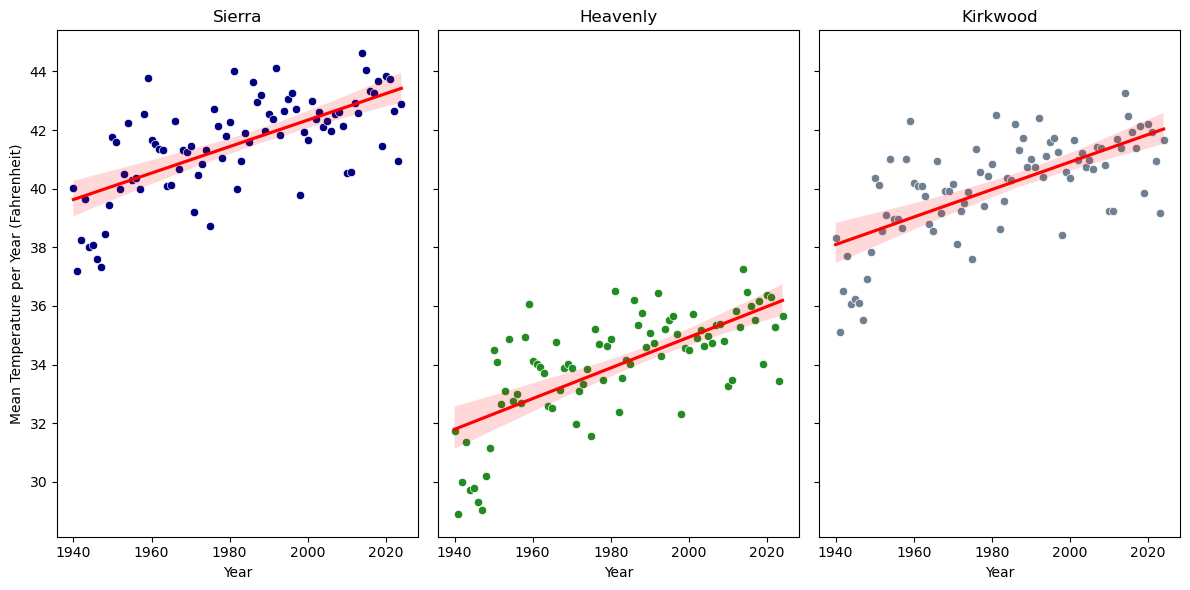

In [259]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

# Sierra
sb.scatterplot(
    data=sierra_annual_mean_temps,
    x='year', y='temp_mean',
    ax=axes[0],
    color='navy'
)
sb.regplot(
    data=sierra_annual_mean_temps,
    x='year', y='temp_mean',
    ax=axes[0],
    scatter=False, color='red'
)
axes[0].set_title("Sierra")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean Temperature per Year (Fahrenheit)")

# Heavenly
sb.scatterplot(
    data=heavenly_annual_mean_temps,
    x='year', y='temp_mean',
    ax=axes[1],
    color='forestgreen'
)
sb.regplot(
    data=heavenly_annual_mean_temps,
    x='year', y='temp_mean',
    ax=axes[1],
    scatter=False, color='red'
)
axes[1].set_title("Heavenly")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("")

# Kirkwood
sb.scatterplot(
    data=kirkwood_annual_mean_temps,
    x='year', y='temp_mean',
    ax=axes[2],
    color='slategray'
)
sb.regplot(
    data=kirkwood_annual_mean_temps,
    x='year', y='temp_mean',
    ax=axes[2],
    scatter=False, color='red'
)
axes[2].set_title("Kirkwood")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig("regression_lines.png", dpi=300, bbox_inches='tight')
plt.show()

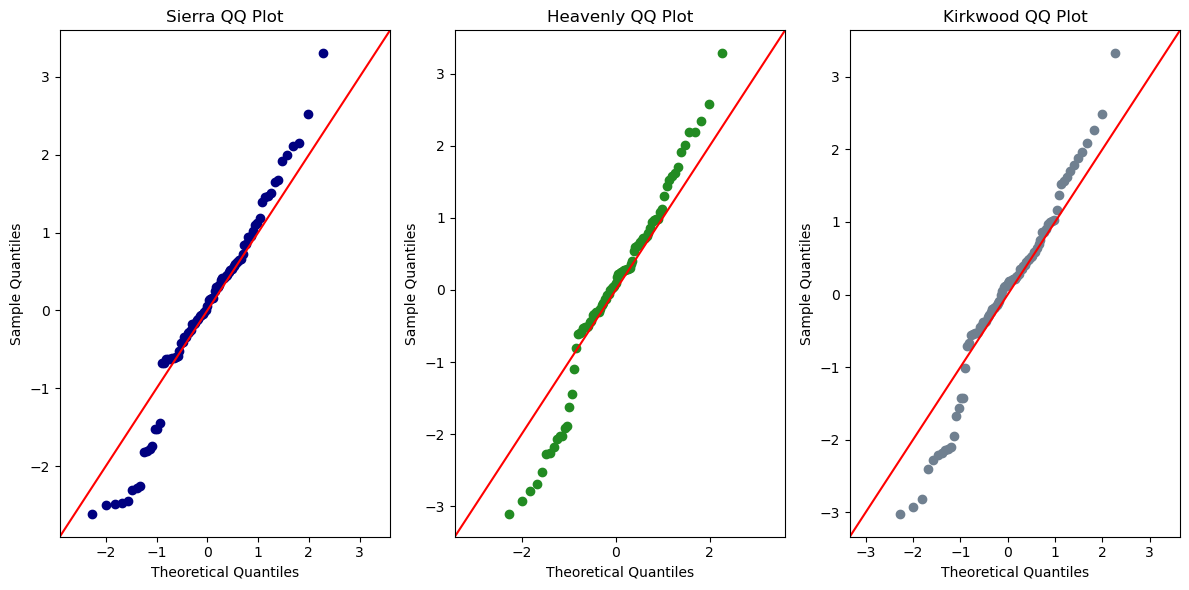

In [258]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Sierra
sm.qqplot(sierra_residuals, line='45', ax=axes[0], markerfacecolor='navy', markeredgecolor='navy')
axes[0].set_title("Sierra QQ Plot")

# Heavenly
sm.qqplot(heavenly_residuals, line='45', ax=axes[1], markerfacecolor='forestgreen', markeredgecolor='forestgreen')
axes[1].set_title("Heavenly QQ Plot")

# Kirkwood
sm.qqplot(kirkwood_residuals, line='45', ax=axes[2], markerfacecolor='slategray', markeredgecolor='slategray')
axes[2].set_title("Kirkwood QQ Plot")

plt.tight_layout()
plt.savefig("qq_plots.png", dpi=300, bbox_inches='tight')
plt.show()